In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#import warnings
#warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc, precision_score, recall_score, f1_score


In [17]:
# loading the dataset 
da = pd.read_csv(r"C:\Users\ayanr\Desktop\DataScienceML\udcustchurnpred\data\Notebook\eda_churndata.csv")
da.head(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0


In [16]:
da.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

In [23]:
# Dropping unnecessary columns form the dataset
da = da.drop(['CustomerId', 'Surname', 'RowNumber'], axis=1)
da.head(4)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0


In [24]:
da.reset_index(drop=True, inplace=True)

In [25]:
da.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [26]:
da.head(4)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0


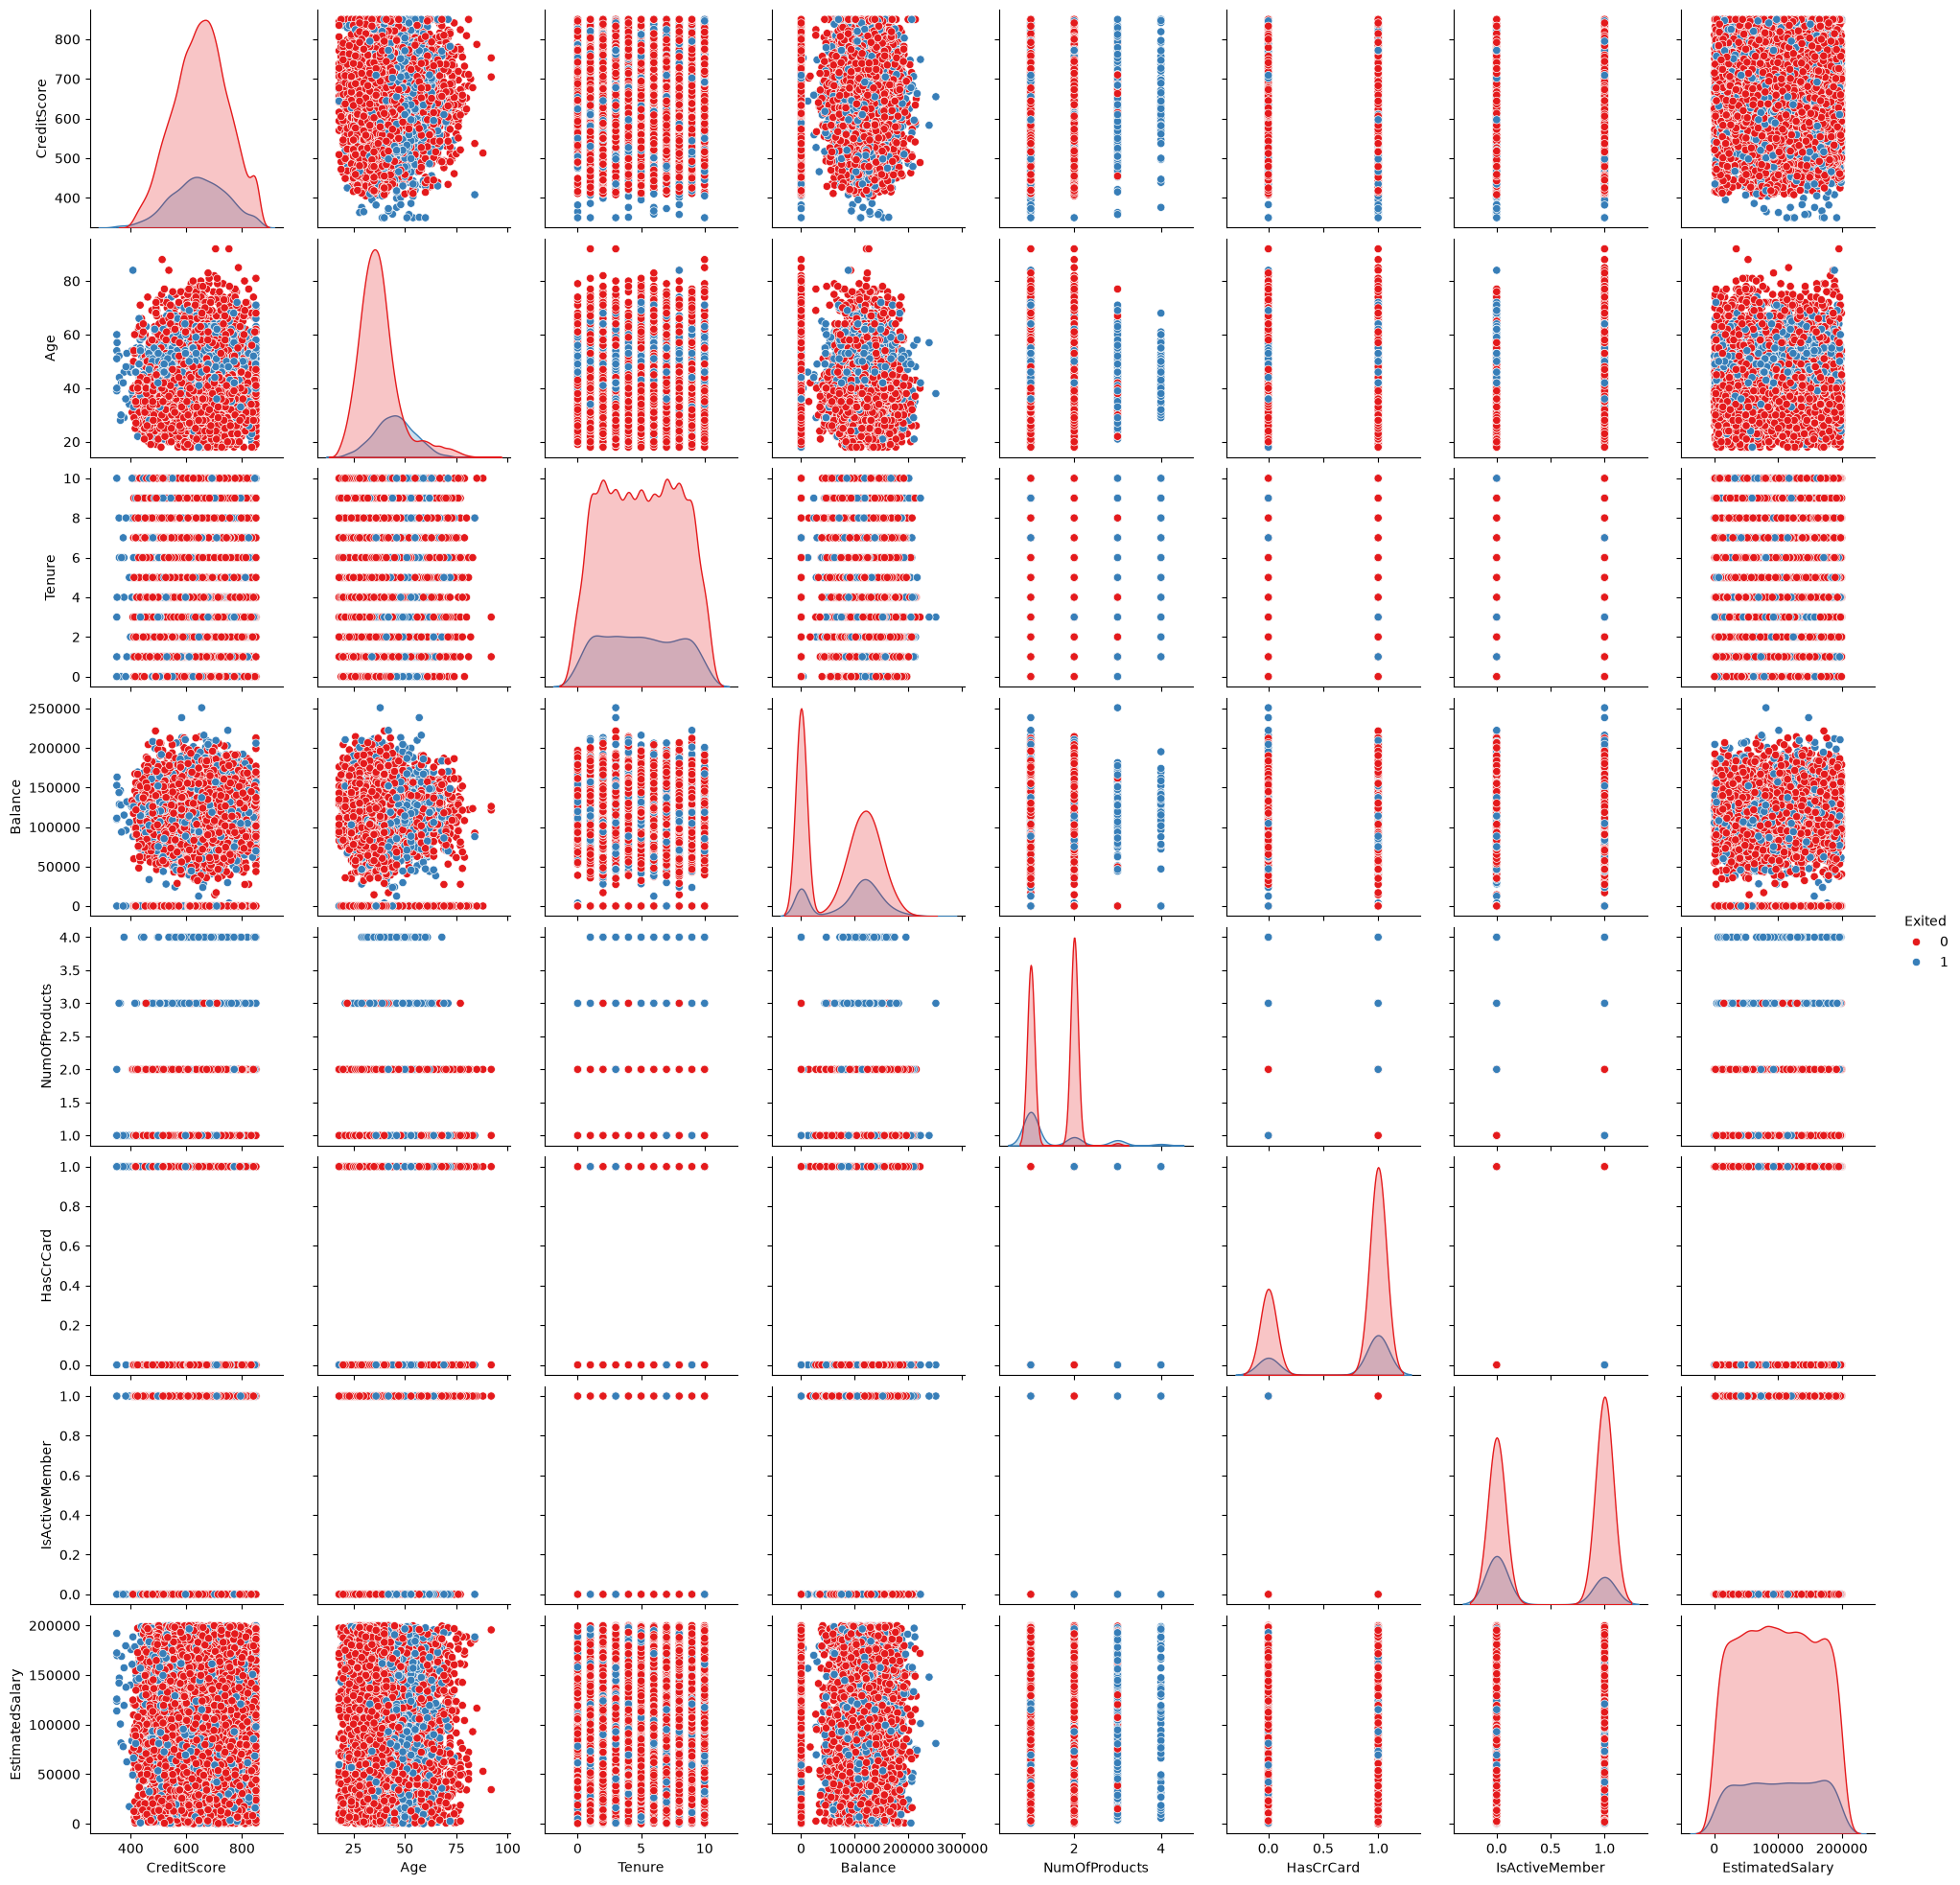

In [14]:
sns.pairplot(da, hue='Exited', palette='Set1', diag_kind='kde')

In [ ]:
# checking the correlation between the features and the target variable
numeric_correlation = da.corr(numeric_only=True)['Exited'].sort_values(ascending=False)
numeric_correlation

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64

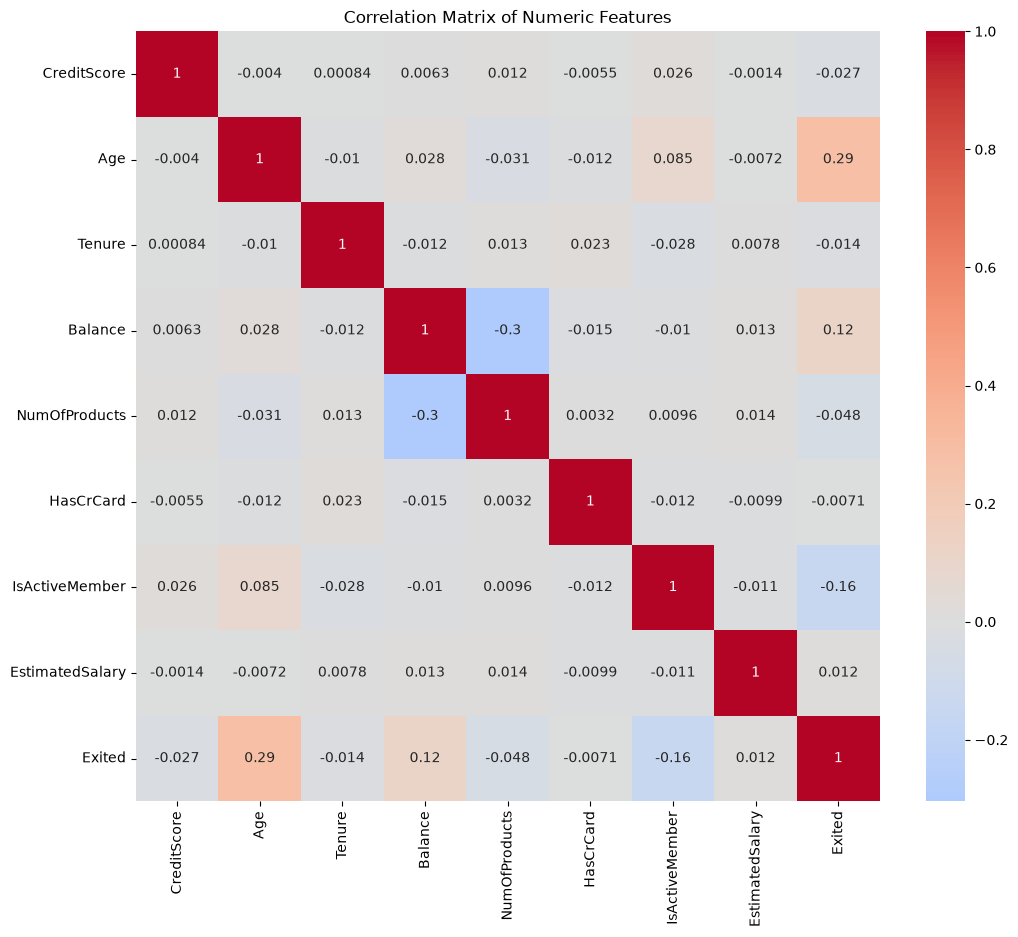

In [28]:
# checking for multi-collinearity among the numeric features using a heatmap

plt.figure(figsize=(12, 10))
sns.heatmap(da.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [29]:
# displaying the correlation matrix of the dataset
corr_matrix = da.corr(numeric_only=True)
corr_matrix

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


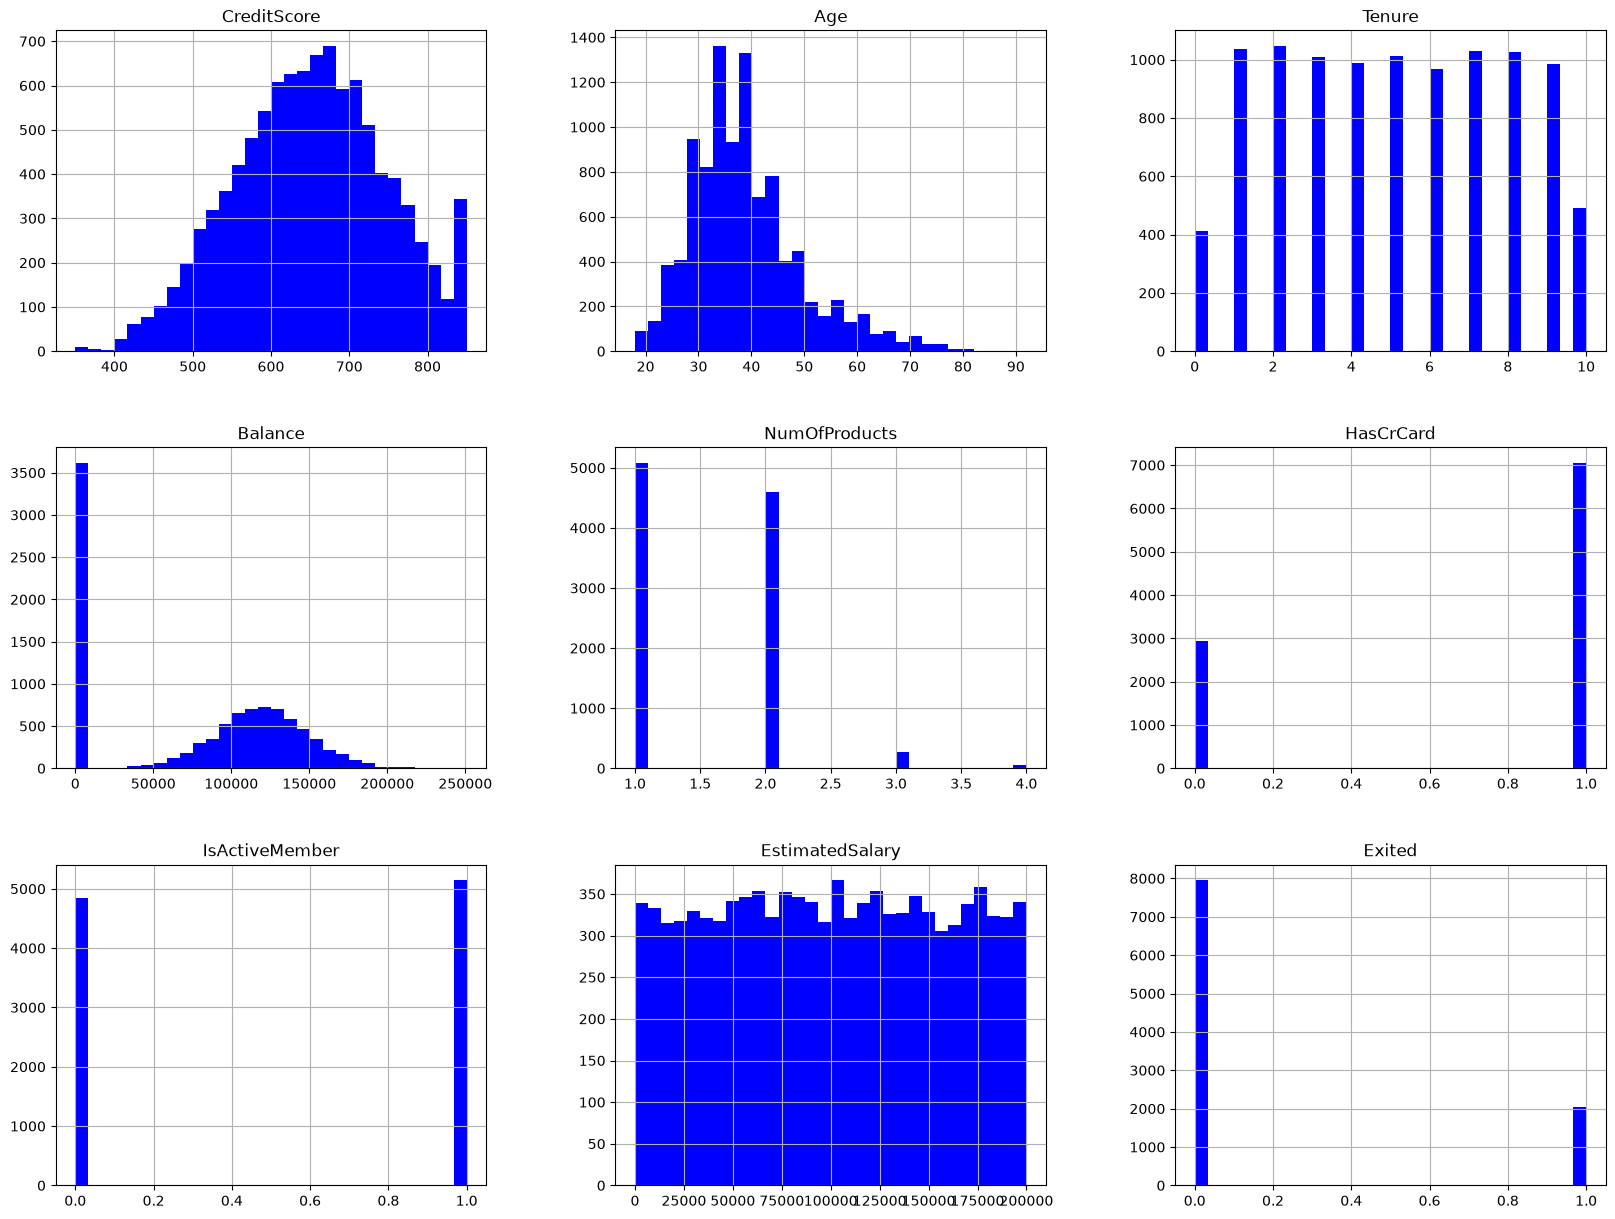

In [ ]:
# Plotting the histogram of the dataset for better 
# understanding of the distribution of the features
da.hist(bins=30, figsize=(20, 15), color='blue')
plt.show()

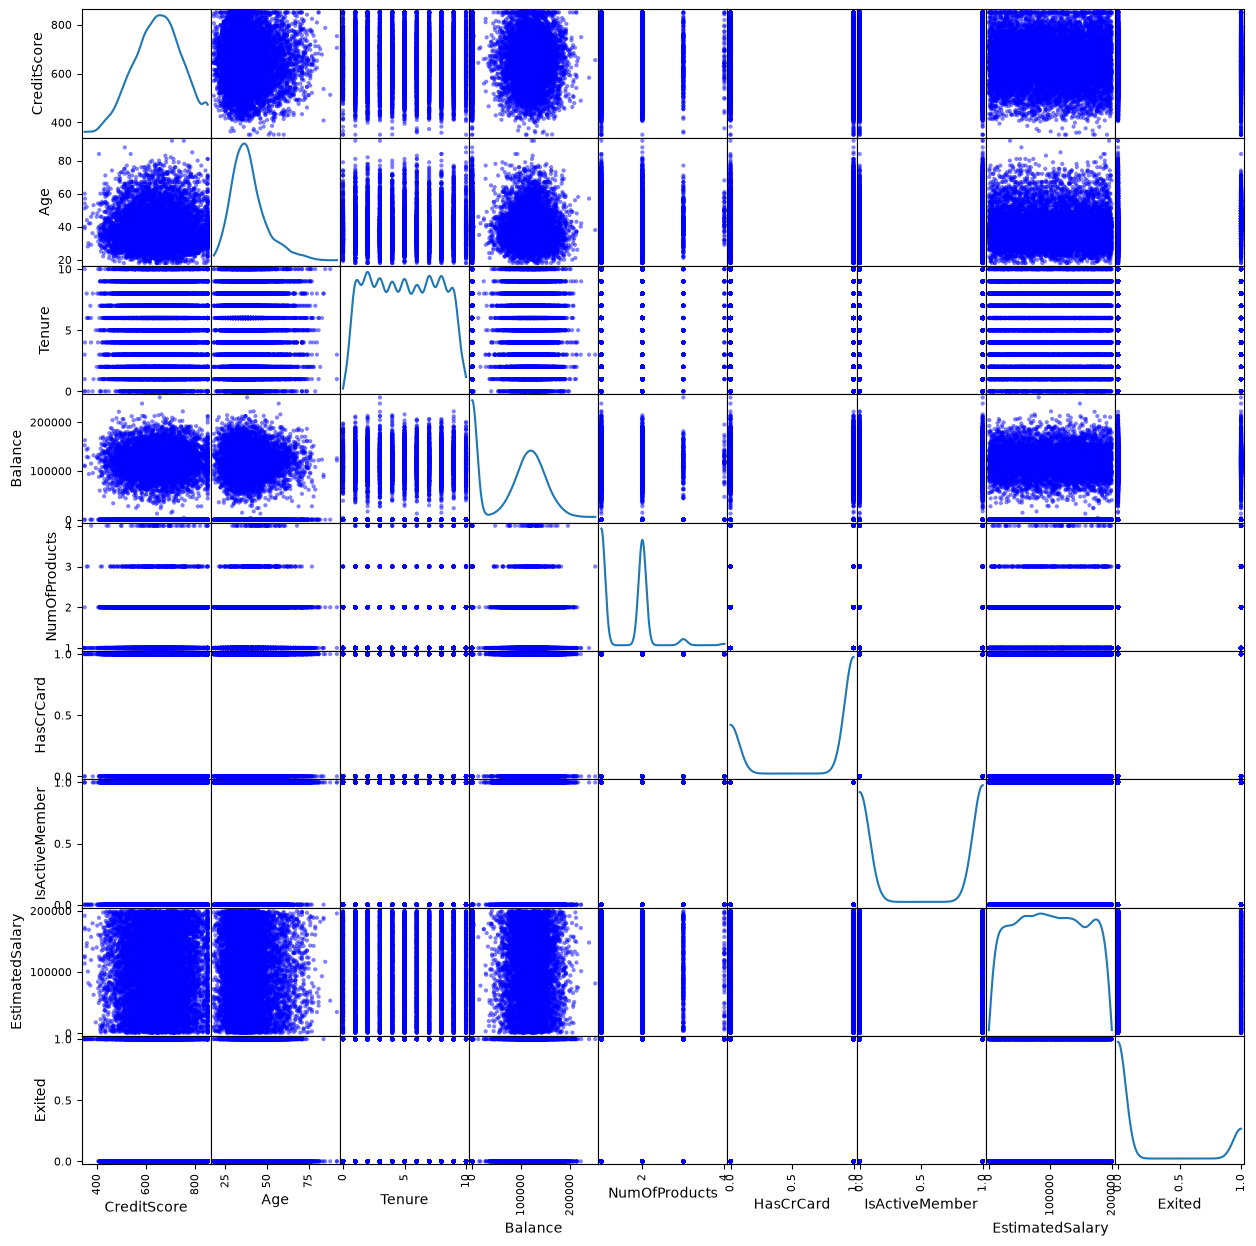

In [31]:
#plotting the correlationn with scatter_matrix
from pandas.plotting import scatter_matrix
scatter_matrix(da, figsize=(15, 15), diagonal='kde', color='blue')
plt.show()

# start from here tomorrow

C:\Users\ayanr\AppData\Local\Temp\ipykernel_21464\2442608188.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:grey'` for the same effect.

  sns.barplot(x='Geography', y='Exited', hue='Gender', color='grey', data=da)


<Axes: xlabel='Geography', ylabel='Exited'>

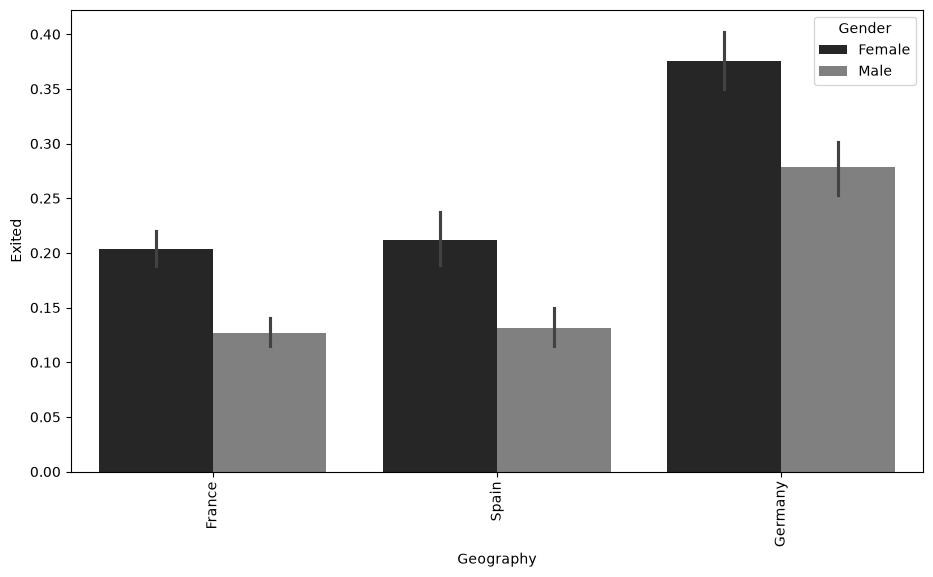

In [4]:
#visualizing the barplot where Exited is on x-axis and Geography is on y axis and key is gender.
plt.figure(figsize=(11, 6))
plt.xticks(rotation=90)
sns.barplot(x='Geography', y='Exited', hue='Gender', color='grey', data=da)

C:\Users\ayanr\AppData\Local\Temp\ipykernel_21464\1735932760.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.barplot(x='Age', y='Exited', hue='Gender', color='red', data=da)


<Axes: xlabel='Age', ylabel='Exited'>

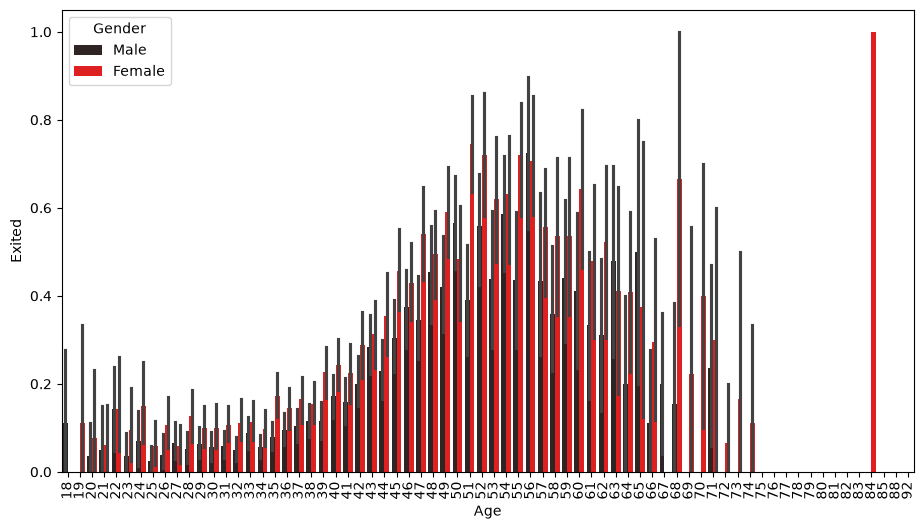

In [5]:
#visualizing the barplot where geography is on x-axis and estimated salary is on y axis and key is gender.
plt.figure(figsize=(11, 6))
plt.xticks(rotation=90)
sns.barplot(x='Age', y='Exited', hue='Gender', color='red', data=da)

C:\Users\ayanr\AppData\Local\Temp\ipykernel_21464\1404775997.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.barplot(x='IsActiveMember', y='Exited', hue='Gender', color='red', data=da)


<Axes: xlabel='IsActiveMember', ylabel='Exited'>

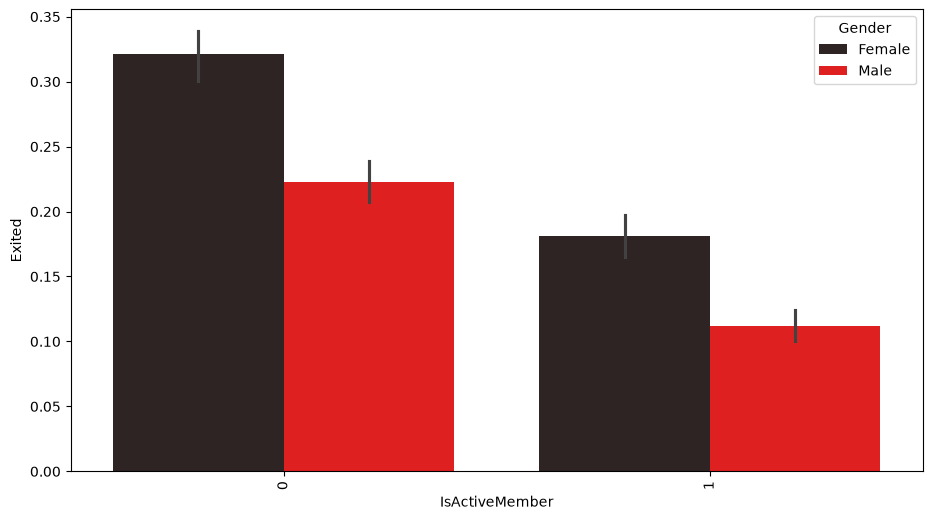

In [6]:
plt.figure(figsize=(11, 6))
plt.xticks(rotation=90)
sns.barplot(x='IsActiveMember', y='Exited', hue='Gender', color='red', data=da)

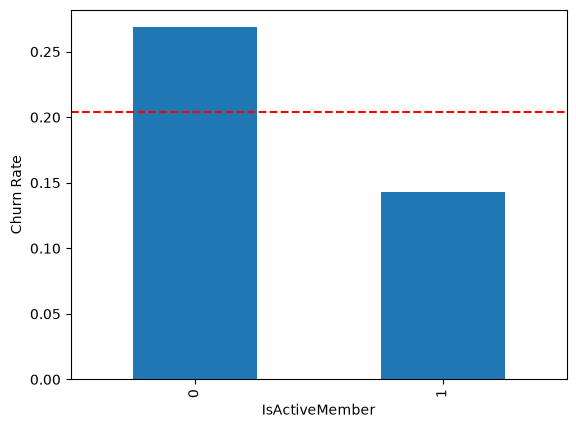

In [7]:
da.groupby("IsActiveMember")["Exited"].mean().plot.bar() 
plt.ylabel("Churn Rate")
plt.xlabel("IsActiveMember")

plt.axhline(da['Exited'].mean(), color='red', linestyle='--', label='Overall Churn average') 
plt.show()

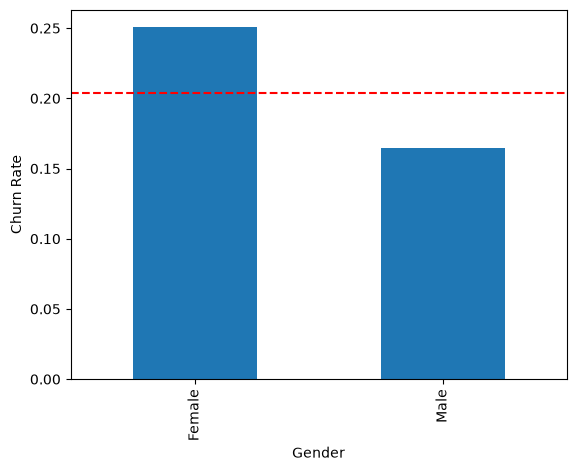

In [8]:
da.groupby("Gender")["Exited"].mean().plot.bar() 
plt.ylabel("Churn Rate")
plt.xlabel("Gender")

plt.axhline(da['Exited'].mean(), color='red', linestyle='--', label='Overall Churn average') 
plt.show()